In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

In [ ]:
os.makedirs("/kaggle/working/output", exist_ok=True)
os.makedirs("/kaggle/working/comparison", exist_ok=True)

print("Output folders created successfully.")

In [3]:
dataset_path = "/kaggle/input/datasets/sp23bse071/document/PNG"

image_paths = sorted(glob.glob(os.path.join(dataset_path, "*.png")))

print(f"Total Images Found: {len(image_paths)}")

Total Images Found: 498


In [4]:
for i, path in enumerate(image_paths[:10]):
    print(f"{i+1}. {path}")

1. /kaggle/input/datasets/sp23bse071/document/PNG/0014c72ba18bc518912766f9e62dd4c96562b8374aa05a2b33ac12bcfa61d78e_0044.png
2. /kaggle/input/datasets/sp23bse071/document/PNG/002c996dbdaf8dc57234f111a1395006a13b736201a614fc70749a11a76f9ef1_0009.png
3. /kaggle/input/datasets/sp23bse071/document/PNG/00532b9611dd141885aabfb3b7377a65f3b5531c9395a3d4fbe52f009fcb60ba_0074.png
4. /kaggle/input/datasets/sp23bse071/document/PNG/008b8f30ce8ecadb7d82dd4c227c9a7c0401e2373cbae940197b8544b9a6dadc_0190.png
5. /kaggle/input/datasets/sp23bse071/document/PNG/00a70221a2cc578a956a1bd6fa9957ae292d9829a2a55c2b03e0df174a76a038_0254.png
6. /kaggle/input/datasets/sp23bse071/document/PNG/011fe76a02d62176240fc69f3ff08a6e24f04cc7a18377cc8abbba01306773f7_0178.png
7. /kaggle/input/datasets/sp23bse071/document/PNG/021fe513286a47a35efd6feb911ab7e25c07f4d73ae06dad0efe0bb4a8c0ec7c_0023.png
8. /kaggle/input/datasets/sp23bse071/document/PNG/023d54c4e72784521d0ab5cd8c052b3c1f0e3fbca092eaf4820b756d185643cf_0014.png
9. /kagg

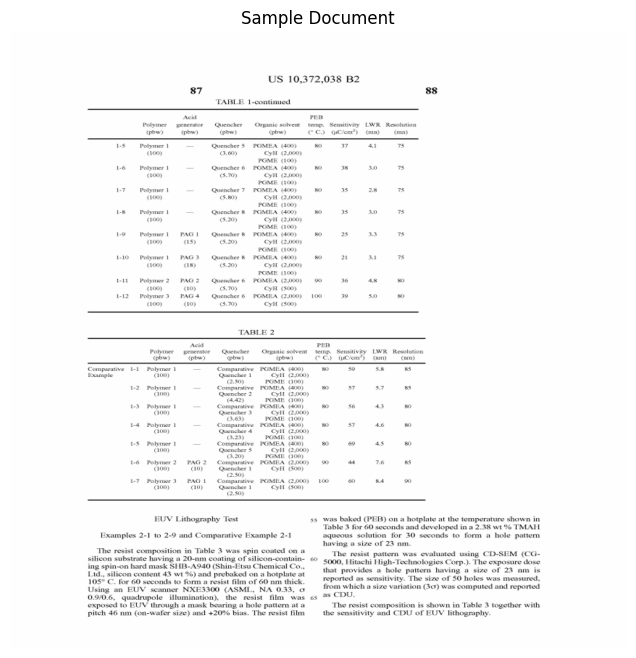

In [5]:
image = cv2.imread(image_paths[0])

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,8))
plt.imshow(image_rgb)
plt.title("Sample Document")
plt.axis("off")
plt.show()

In [6]:
# Select first 10 images
selected_images = image_paths[:10]

print("Selected Images:")

for i, path in enumerate(selected_images):
    print(f"{i+1}. {os.path.basename(path)}")

Selected Images:
1. 0014c72ba18bc518912766f9e62dd4c96562b8374aa05a2b33ac12bcfa61d78e_0044.png
2. 002c996dbdaf8dc57234f111a1395006a13b736201a614fc70749a11a76f9ef1_0009.png
3. 00532b9611dd141885aabfb3b7377a65f3b5531c9395a3d4fbe52f009fcb60ba_0074.png
4. 008b8f30ce8ecadb7d82dd4c227c9a7c0401e2373cbae940197b8544b9a6dadc_0190.png
5. 00a70221a2cc578a956a1bd6fa9957ae292d9829a2a55c2b03e0df174a76a038_0254.png
6. 011fe76a02d62176240fc69f3ff08a6e24f04cc7a18377cc8abbba01306773f7_0178.png
7. 021fe513286a47a35efd6feb911ab7e25c07f4d73ae06dad0efe0bb4a8c0ec7c_0023.png
8. 023d54c4e72784521d0ab5cd8c052b3c1f0e3fbca092eaf4820b756d185643cf_0014.png
9. 02770edb71e446fcb199754ec014418cfa4666efb4a9b78c68449bc5f6752ce1_0079.png
10. 02baa8210f8028475b9bbf9a647b5c0fbe25842f2bf11198cd2536a5cc6e95d7_0056.png


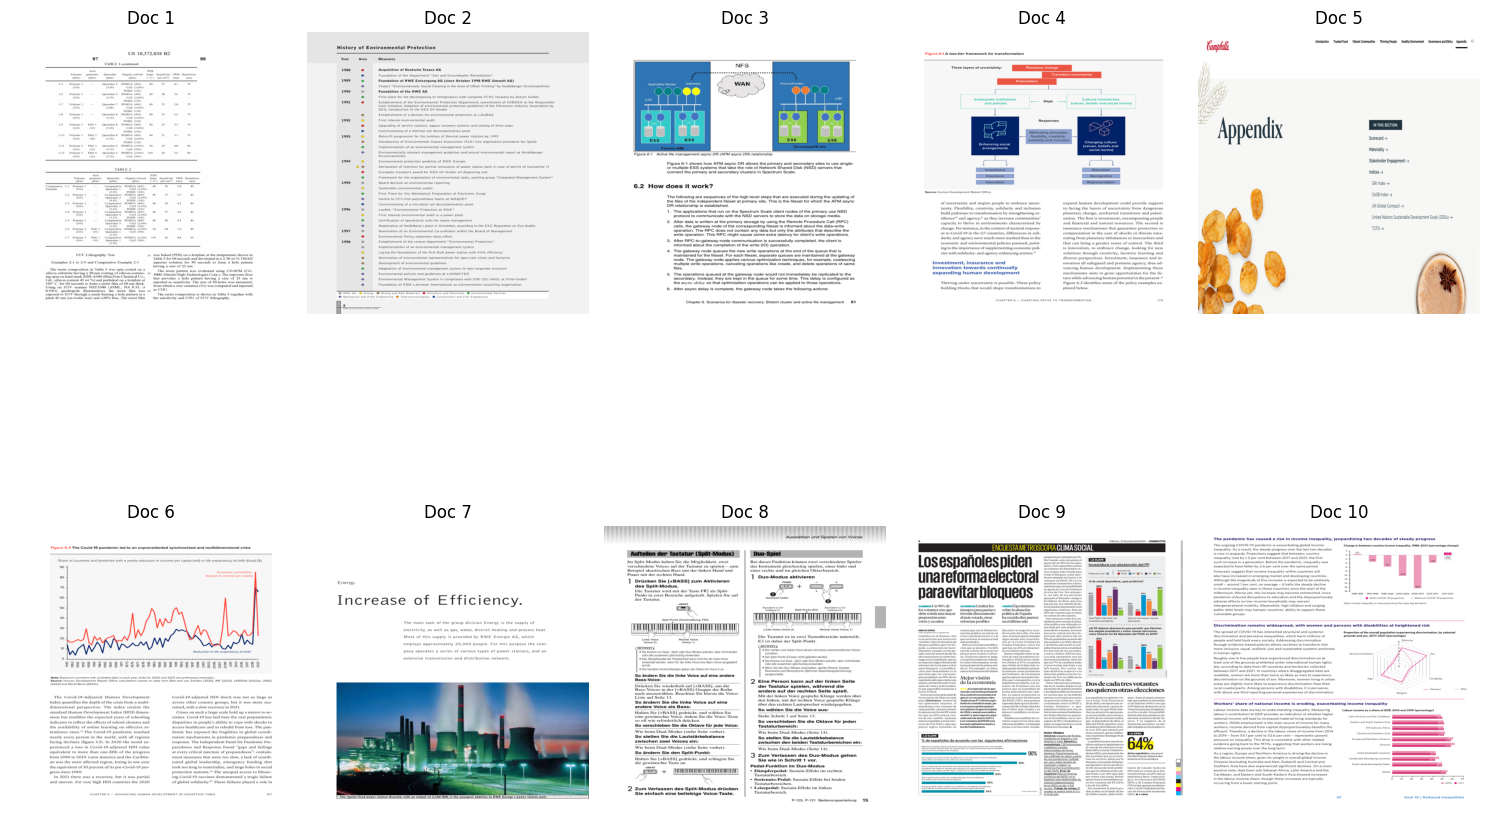

In [7]:
plt.figure(figsize=(15, 12))

for i, path in enumerate(selected_images):
    image = cv2.imread(path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 5, i + 1)
    plt.imshow(image)
    plt.title(f"Doc {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Create folder for tilted images
os.makedirs("/kaggle/working/tilted", exist_ok=True)

# Use images 6 to 10
tilted_images = selected_images[5:]

for i, path in enumerate(tilted_images):

    image = cv2.imread(path)

    h, w = image.shape[:2]

    # Original corner points
    src = np.float32([
        [0, 0],
        [w-1, 0],
        [w-1, h-1],
        [0, h-1]
    ])

    # New corner points (simulate camera tilt)
    dst = np.float32([
        [80, 120],
        [w-120, 40],
        [w-50, h-80],
        [120, h-20]
    ])

    # Perspective transformation matrix
    matrix = cv2.getPerspectiveTransform(src, dst)

    # Apply transformation
    tilted = cv2.warpPerspective(image, matrix, (w, h))

    # Save tilted image
    cv2.imwrite(f"/kaggle/working/tilted/tilted_{i+1}.png", tilted)

print("5 tilted images created successfully!")

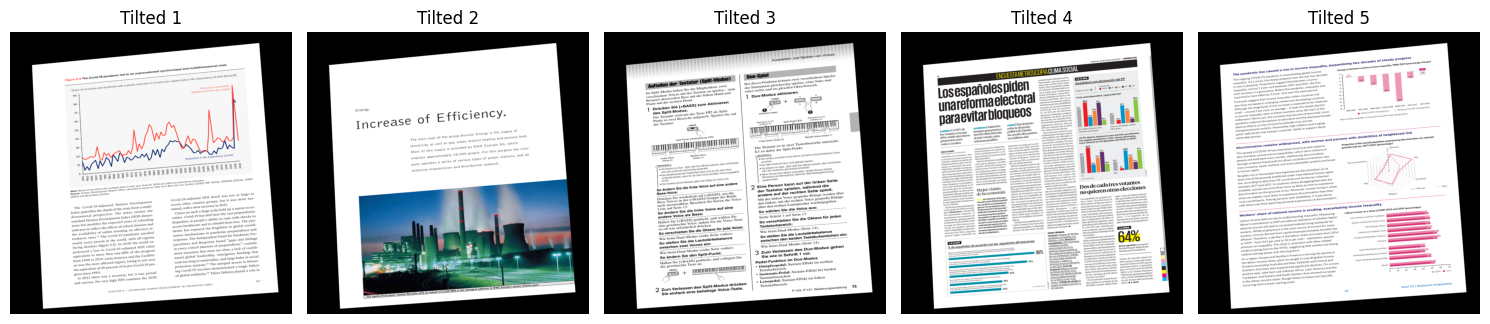

In [9]:
tilted_paths = sorted(glob.glob("/kaggle/working/tilted/*.png"))

plt.figure(figsize=(15, 8))

for i, path in enumerate(tilted_paths):

    image = cv2.imread(path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 5, i + 1)
    plt.imshow(image)
    plt.title(f"Tilted {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

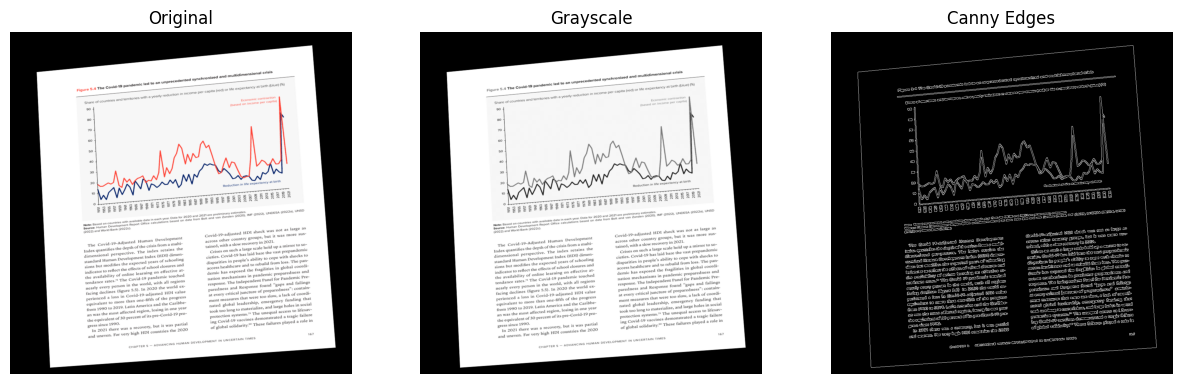

In [10]:
# Read one tilted image
image = cv2.imread(tilted_paths[0])

original = image.copy()

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Reduce noise
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# Detect edges
edges = cv2.Canny(blur, 75, 200)

# Display each step
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edges")
plt.axis("off")

plt.show()

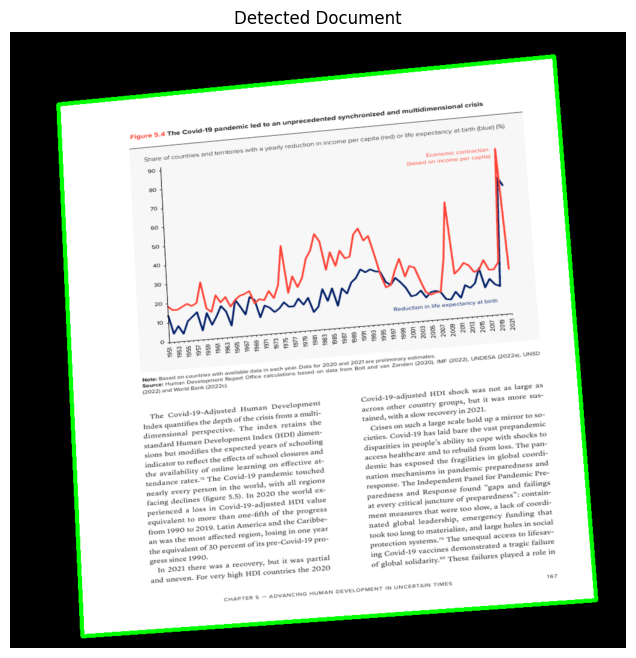

In [11]:
# Find contours
contours, _ = cv2.findContours(edges.copy(),
                               cv2.RETR_LIST,
                               cv2.CHAIN_APPROX_SIMPLE)

# Sort contours by area
contours = sorted(contours, key=cv2.contourArea, reverse=True)

document_contour = None

# Find the first contour with four corners
for contour in contours:

    perimeter = cv2.arcLength(contour, True)

    approx = cv2.approxPolyDP(contour,
                              0.02 * perimeter,
                              True)

    if len(approx) == 4:
        document_contour = approx
        break

# Draw contour
output = original.copy()

cv2.drawContours(output,
                 [document_contour],
                 -1,
                 (0,255,0),
                 5)

plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Detected Document")
plt.axis("off")
plt.show()

In [12]:
def order_points(points):
    """
    Order points as:
    Top-Left, Top-Right, Bottom-Right, Bottom-Left
    """

    points = points.reshape(4, 2)

    rect = np.zeros((4, 2), dtype="float32")

    s = points.sum(axis=1)
    rect[0] = points[np.argmin(s)]   # Top Left
    rect[2] = points[np.argmax(s)]   # Bottom Right

    diff = np.diff(points, axis=1)
    rect[1] = points[np.argmin(diff)]  # Top Right
    rect[3] = points[np.argmax(diff)]  # Bottom Left

    return rect

In [13]:
# Order the detected corners
rect = order_points(document_contour)

(tl, tr, br, bl) = rect

# Compute width
widthA = np.linalg.norm(br - bl)
widthB = np.linalg.norm(tr - tl)

maxWidth = int(max(widthA, widthB))

# Compute height
heightA = np.linalg.norm(tr - br)
heightB = np.linalg.norm(tl - bl)

maxHeight = int(max(heightA, heightB))

# Destination points
destination = np.array([
    [0, 0],
    [maxWidth - 1, 0],
    [maxWidth - 1, maxHeight - 1],
    [0, maxHeight - 1]
], dtype="float32")

# Perspective matrix
matrix = cv2.getPerspectiveTransform(rect, destination)

# Warp image
warped = cv2.warpPerspective(original,
                             matrix,
                             (maxWidth, maxHeight))

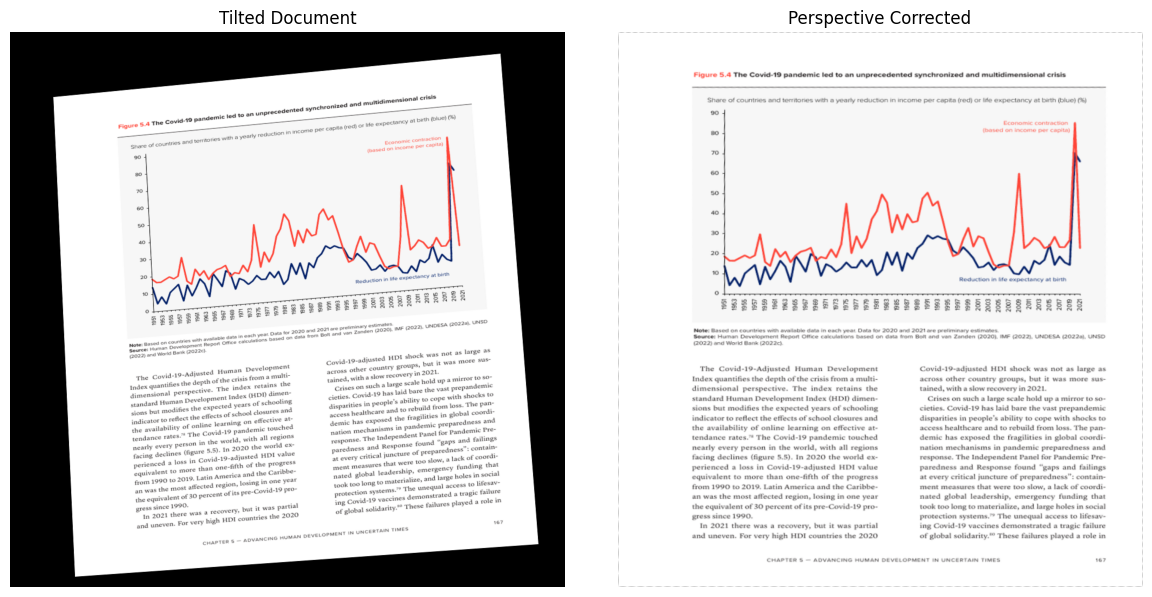

In [14]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.title("Tilted Document")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
plt.title("Perspective Corrected")
plt.axis("off")

plt.tight_layout()
plt.show()

In [15]:
def enhance_document(image):

    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Reduce noise
    denoised = cv2.bilateralFilter(gray, 9, 75, 75)

    # Increase brightness and contrast
    enhanced = cv2.convertScaleAbs(
        denoised,
        alpha=1.4,   # Contrast
        beta=20       # Brightness
    )

    # Sharpen
    kernel = np.array([
        [0,-1,0],
        [-1,5,-1],
        [0,-1,0]
    ])

    sharpened = cv2.filter2D(enhanced, -1, kernel)

    return sharpened

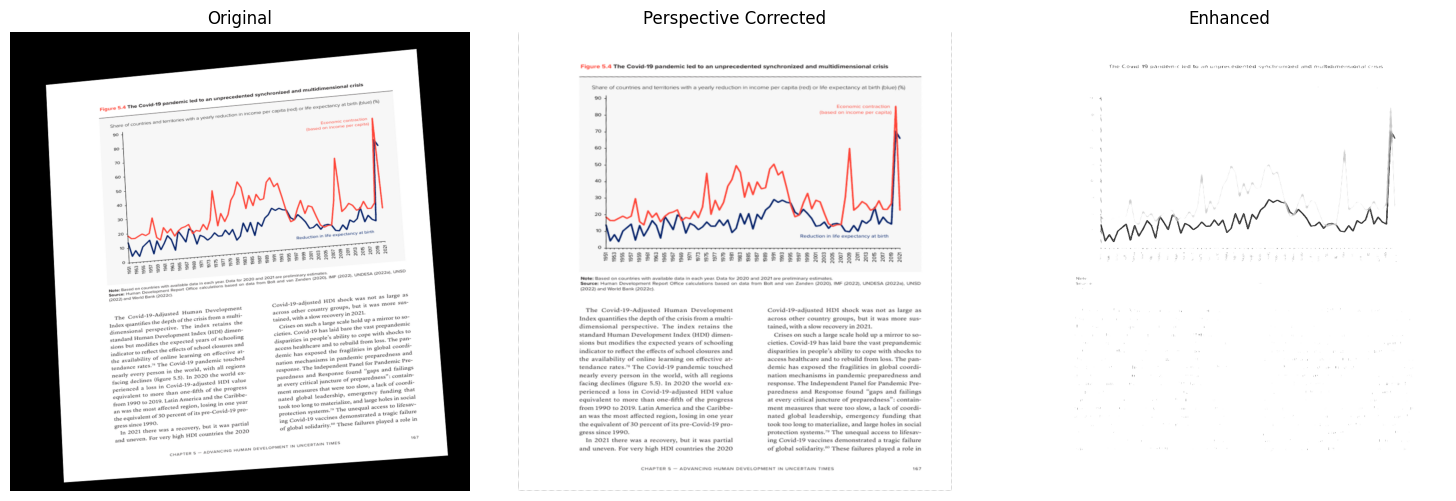

In [16]:
enhanced = enhance_document(warped)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
plt.title("Perspective Corrected")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(enhanced, cmap="gray")
plt.title("Enhanced")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
for index, path in enumerate(selected_images):

    image = cv2.imread(path)
    original = image.copy()

    # ----------------------------------------------------
    # Images 1-5: Already straight
    # ----------------------------------------------------
    if index < 5:

        enhanced = enhance_document(image)

        cv2.imwrite(
            f"/kaggle/working/output/enhanced_doc_{index+1}.png",
            enhanced
        )

        plt.figure(figsize=(15,5))

        plt.subplot(1,2,1)
        plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
        plt.title("Original")

        plt.axis("off")

        plt.subplot(1,2,2)
        plt.imshow(enhanced, cmap="gray")
        plt.title("Enhanced")

        plt.axis("off")

        plt.tight_layout()

        plt.savefig(
            f"/kaggle/working/comparison/comparison_{index+1}.png"
        )

        plt.close()

    # ----------------------------------------------------
    # Images 6-10: Tilt + Correct + Enhance
    # ----------------------------------------------------
    else:

        h, w = image.shape[:2]

        src = np.float32([
            [0,0],
            [w-1,0],
            [w-1,h-1],
            [0,h-1]
        ])

        dst = np.float32([
            [80,120],
            [w-120,40],
            [w-50,h-80],
            [120,h-20]
        ])

        M = cv2.getPerspectiveTransform(src,dst)

        tilted = cv2.warpPerspective(image,M,(w,h))

        gray = cv2.cvtColor(tilted,cv2.COLOR_BGR2GRAY)
        blur = cv2.GaussianBlur(gray,(5,5),0)
        edges = cv2.Canny(blur,75,200)

        contours,_ = cv2.findContours(
            edges,
            cv2.RETR_LIST,
            cv2.CHAIN_APPROX_SIMPLE
        )

        contours = sorted(
            contours,
            key=cv2.contourArea,
            reverse=True
        )

        document = None

        for contour in contours:

            peri = cv2.arcLength(contour,True)

            approx = cv2.approxPolyDP(
                contour,
                0.02*peri,
                True
            )

            if len(approx)==4:
                document = approx
                break

        if document is None:
            print(f"Skipping {index+1}")
            continue

        rect = order_points(document)

        (tl,tr,br,bl)=rect

        widthA=np.linalg.norm(br-bl)
        widthB=np.linalg.norm(tr-tl)

        maxWidth=int(max(widthA,widthB))

        heightA=np.linalg.norm(tr-br)
        heightB=np.linalg.norm(tl-bl)

        maxHeight=int(max(heightA,heightB))

        destination=np.array([
            [0,0],
            [maxWidth-1,0],
            [maxWidth-1,maxHeight-1],
            [0,maxHeight-1]
        ],dtype="float32")

        matrix=cv2.getPerspectiveTransform(rect,destination)

        corrected=cv2.warpPerspective(
            tilted,
            matrix,
            (maxWidth,maxHeight)
        )

        enhanced=enhance_document(corrected)

        cv2.imwrite(
            f"/kaggle/working/output/enhanced_doc_{index+1}.png",
            enhanced
        )

        plt.figure(figsize=(15,5))

        plt.subplot(1,3,1)
        plt.imshow(cv2.cvtColor(tilted,cv2.COLOR_BGR2RGB))
        plt.title("Tilted")

        plt.axis("off")

        plt.subplot(1,3,2)
        plt.imshow(cv2.cvtColor(corrected,cv2.COLOR_BGR2RGB))
        plt.title("Corrected")

        plt.axis("off")

        plt.subplot(1,3,3)
        plt.imshow(enhanced,cmap="gray")
        plt.title("Enhanced")

        plt.axis("off")

        plt.tight_layout()

        plt.savefig(
            f"/kaggle/working/comparison/comparison_{index+1}.png"
        )

        plt.close()

print("Project Completed Successfully!")

In [ ]:
import shutil

shutil.make_archive(
    "/kaggle/working/Document_Image_Enhancement",
    "zip",
    "/kaggle/working"
)

print("Document_Image_Enhancement.zip created")